# VSLM Models Evaluation on Kvasir-VQA-x1

Evaluate four Vision Small Language Models (VSLMs) and compare their performance
against the BLIP-2 zero-shot baseline on the Kvasir-VQA-x1 medical VQA dataset.

**Models evaluated:**
1. **MoE-TinyMed** (~3.6B, 2B active) — Medical-specific MoE architecture
2. **BiomedGPT** (182M–930M) — Lightweight biomedical generalist
3. **TinyGPT-V** (2.8B) — Smallest general-purpose VLM
4. **MiniGPT-4** (~7B) — Larger general VLM (InstructBLIP-Vicuna)

**Baseline:** BLIP-2 (`Salesforce/blip2-opt-2.7b`) — Zero-shot, ~2.7B params

**Metrics:** Exact Match Accuracy, Word-level F1 Score, Per-complexity breakdown

**Prerequisites:**
- GPU Runtime enabled (`Runtime > Change runtime type > T4 GPU`)
- Project data uploaded to Google Drive OR download fresh in Colab

## 1. Install Dependencies

In [1]:
!pip install -q datasets transformers accelerate pillow pandas tqdm
!pip install -q einops bitsandbytes sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00


## 2. Configuration

Set `USE_DRIVE = True` if you uploaded the project to Google Drive.
Set `USE_DRIVE = False` to download everything fresh.

In [3]:
import os
import json
import torch
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# ========== CHANGE THIS ==========
USE_DRIVE = False
NUM_SAMPLES = 20  # Number of test samples per model
# =================================

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # UPDATE THIS PATH to match your Google Drive folder
    PROJECT_DIR = "/content/drive/MyDrive/AI-ML-based-approaches-for-the-medical-sector"
else:
    PROJECT_DIR = "/content/medical-vqa"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
IMAGE_DIR = os.path.join(DATA_DIR, "images")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", "predictions")
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_NEW_TOKENS = 64

print(f"Project dir: {PROJECT_DIR}")
print(f"Data dir:    {DATA_DIR}")
print(f"Image dir:   {IMAGE_DIR}")
print(f"Device:      {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    # print(f"GPU Memory:  {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

Project dir: /content/medical-vqa
Data dir:    /content/medical-vqa/data
Image dir:   /content/medical-vqa/data/images
Device:      cuda
GPU:         Tesla T4


## 3. Download Dataset (Only if USE_DRIVE = False)

Skip this cell if you already have the data on Google Drive.

In [4]:
if not USE_DRIVE:
    from datasets import load_dataset

    os.makedirs(IMAGE_DIR, exist_ok=True)

    # Download images
    print("[INFO] Downloading images from SimulaMet-HOST/Kvasir-VQA...")
    ds_host = load_dataset("SimulaMet-HOST/Kvasir-VQA", split="raw")
    seen = set()
    for row in tqdm(ds_host, desc="Saving images"):
        if row["img_id"] not in seen:
            row["image"].save(os.path.join(IMAGE_DIR, f"{row['img_id']}.jpg"))
            seen.add(row["img_id"])
    print(f"[INFO] Saved {len(seen)} images")

    # Download QA pairs
    for split in ["train", "test"]:
        print(f"[INFO] Downloading {split} split...")
        ds = load_dataset("SimulaMet/Kvasir-VQA-x1", split=split)
        records = []
        for row in tqdm(ds, desc=f"Processing {split}"):
            records.append({
                "img_id": row["img_id"],
                "complexity": row["complexity"],
                "question": row["question"],
                "answer": row["answer"],
                "question_class": row["question_class"],
                "original": json.dumps(row["original"]) if row.get("original") else ""
            })
        df = pd.DataFrame(records)
        df.to_csv(os.path.join(DATA_DIR, f"kvasir_vqa_x1_{split}.csv"), index=False)
        print(f"[INFO] Saved {len(df)} {split} samples")
else:
    print("[INFO] Using data from Google Drive. Skipping download.")

[INFO] Downloading images from SimulaMet-HOST/Kvasir-VQA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

...

Generating test split:   0%|          | 0/15955 [00:00<?, ? examples/s]

Processing train:   0%|          | 0/143594 [00:00<?, ?it/s]

[INFO] Saved 143594 train samples
[INFO] Downloading test split...


Processing test:   0%|          | 0/15955 [00:00<?, ?it/s]

[INFO] Saved 15955 test samples


## 4. Shared Evaluation Utilities

Same metrics as the baseline: **Exact Match** and **Word-level F1 Score**.

In [5]:
def compute_word_f1(prediction, ground_truth):
    """Compute word-level F1 score between prediction and ground truth."""
    pred_tokens = set(prediction.strip().lower().split())
    gt_tokens = set(ground_truth.strip().lower().split())

    if not pred_tokens or not gt_tokens:
        return 0.0

    common = pred_tokens & gt_tokens
    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gt_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return f1


def select_diverse_samples(df, n_samples, seed=42):
    """Select diverse samples across complexity levels."""
    samples = []
    for complexity in sorted(df["complexity"].unique()):
        subset = df[df["complexity"] == complexity]
        n = max(1, n_samples // 3)
        samples.append(subset.sample(n=min(n, len(subset)), random_state=seed))
    return pd.concat(samples).head(n_samples)


def evaluate_single(row, prediction):
    """Process a single inference result."""
    ground_truth = str(row["answer"])
    is_exact = prediction.strip().lower() == ground_truth.strip().lower()
    f1_score = compute_word_f1(prediction, ground_truth)
    return {
        "img_id": row["img_id"],
        "complexity": int(row["complexity"]),
        "question_class": row["question_class"],
        "question": row["question"],
        "ground_truth": ground_truth,
        "prediction": prediction,
        "exact_match": is_exact,
        "word_f1": round(f1_score, 3),
    }


def compute_summary(results, model_name):
    """Compute evaluation summary from results list."""
    if not results:
        return {"model": model_name, "error": "No results"}

    total = len(results)
    exact_matches = sum(1 for r in results if r["exact_match"])
    total_f1 = sum(r["word_f1"] for r in results)
    partial_matches = sum(1 for r in results if r["word_f1"] >= 0.5)

    exact_acc = (exact_matches / total * 100) if total > 0 else 0
    avg_f1 = (total_f1 / total * 100) if total > 0 else 0

    results_df = pd.DataFrame(results)
    per_complexity = {}
    for c in sorted(results_df["complexity"].unique()):
        c_df = results_df[results_df["complexity"] == c]
        per_complexity[f"level_{c}"] = {
            "exact_matches": int(c_df["exact_match"].sum()),
            "total": int(len(c_df)),
            "exact_accuracy": round(c_df["exact_match"].mean() * 100, 1),
            "avg_word_f1": round(c_df["word_f1"].mean() * 100, 1),
        }

    return {
        "model": model_name,
        "num_samples": total,
        "exact_match_accuracy": round(exact_acc, 1),
        "average_word_f1": round(avg_f1, 1),
        "exact_matches": exact_matches,
        "partial_matches_f1_gte_50": partial_matches,
        "total": total,
        "per_complexity": per_complexity,
    }


def print_eval_summary(summary):
    """Print formatted evaluation summary."""
    name = summary.get('model', 'Unknown')
    print(f"\n{'=' * 65}")
    print(f"  {name.upper()} — EVALUATION SUMMARY")
    print(f"{'=' * 65}")
    print(f"  Total samples:            {summary['total']}")
    print(f"  Exact matches:            {summary['exact_matches']}/{summary['total']} ({summary['exact_match_accuracy']:.1f}%)")
    print(f"  Partial matches (F1>=0.5): {summary['partial_matches_f1_gte_50']}/{summary['total']}")
    print(f"  Average Word F1:          {summary['average_word_f1']:.1f}%")
    print(f"\n  Per-Complexity:")
    for key, val in summary.get('per_complexity', {}).items():
        level = key.replace('level_', '')
        print(f"    Level {level}: Exact {val['exact_matches']}/{val['total']}, Avg F1: {val['avg_word_f1']:.1f}%")
    print(f"{'=' * 65}")


def save_model_results(results, model_key):
    """Save predictions CSV and summary JSON."""
    summary = compute_summary(results, model_key)

    results_df = pd.DataFrame(results)
    pred_path = os.path.join(RESULTS_DIR, f"{model_key}_predictions.csv")
    results_df.to_csv(pred_path, index=False)

    summary_path = os.path.join(RESULTS_DIR, f"{model_key}_summary.json")
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[INFO] Predictions saved to {pred_path}")
    print(f"[INFO] Summary saved to {summary_path}")
    return summary

print("Evaluation utilities loaded.")

Evaluation utilities loaded.


## 5. Load Test Data & Select Samples

In [6]:
test_csv = os.path.join(DATA_DIR, "kvasir_vqa_x1_test.csv")
test_df = pd.read_csv(test_csv)
print(f"Test set: {len(test_df)} samples")

sample_df = select_diverse_samples(test_df, NUM_SAMPLES)
print(f"\nSelected {len(sample_df)} diverse samples:")
print(sample_df["complexity"].value_counts().sort_index().to_string())

Test set: 15955 samples

Selected 18 diverse samples:
complexity
1    6
2    6
3    6


## 6. Load Baseline Results

Load the existing BLIP-2 baseline summary for comparison.

In [7]:
# Collect all summaries for final comparison
all_summaries = {}

# Load baseline summary
baseline_summary_path = os.path.join(RESULTS_DIR, "baseline_summary.json")
if os.path.exists(baseline_summary_path):
    with open(baseline_summary_path, "r") as f:
        baseline_summary = json.load(f)
    baseline_summary["model"] = "BLIP-2 (Baseline)"
    all_summaries["BLIP-2 (Baseline)"] = baseline_summary
    print_eval_summary(baseline_summary)
else:
    print("[WARNING] Baseline summary not found. Run baseline_inference first.")
    # Use the known baseline results from README
    baseline_summary = {
        "model": "BLIP-2 (Baseline)",
        "num_samples": 18,
        "exact_match_accuracy": 0.0,
        "average_word_f1": 27.0,
        "exact_matches": 0,
        "partial_matches_f1_gte_50": 1,
        "total": 18,
        "per_complexity": {
            "level_1": {"exact_matches": 0, "total": 6, "exact_accuracy": 0.0, "avg_word_f1": 18.9},
            "level_2": {"exact_matches": 0, "total": 6, "exact_accuracy": 0.0, "avg_word_f1": 27.0},
            "level_3": {"exact_matches": 0, "total": 6, "exact_accuracy": 0.0, "avg_word_f1": 35.1}
        }
    }
    all_summaries["BLIP-2 (Baseline)"] = baseline_summary
    print("[INFO] Using known baseline values from README.")
    print_eval_summary(baseline_summary)

[WARNING] Baseline summary not found. Run baseline_inference first.
[INFO] Using known baseline values from README.

  BLIP-2 (BASELINE) — EVALUATION SUMMARY
  Total samples:            18
  Exact matches:            0/18 (0.0%)
  Partial matches (F1>=0.5): 1/18
  Average Word F1:          27.0%

  Per-Complexity:
    Level 1: Exact 0/6, Avg F1: 18.9%
    Level 2: Exact 0/6, Avg F1: 27.0%
    Level 3: Exact 0/6, Avg F1: 35.1%


---
## 7. Generic Model Evaluation Function

A reusable function that runs inference for any Vision-Language Model.

In [8]:
def run_model_evaluation(model, processor, model_name, model_key,
                         is_encoder_decoder=False, is_instructblip=False):
    """
    Run evaluation for a loaded model on the selected test samples.

    Args:
        model: Loaded model
        processor: Model processor/tokenizer
        model_name: Display name (e.g., 'MoE-TinyMed')
        model_key: File-safe key (e.g., 'moe_tinymed')
        is_encoder_decoder: True for seq2seq models (BiomedGPT)
        is_instructblip: True for InstructBLIP/BLIP-2 models

    Returns:
        dict: Evaluation summary
    """
    results = []
    print(f"\n[INFO] Running {model_name} inference on {len(sample_df)} samples...\n")
    print("=" * 80)

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        img_path = os.path.join(IMAGE_DIR, f"{row['img_id']}.jpg")

        if not os.path.exists(img_path):
            print(f"[SKIP] Image not found: {row['img_id']}")
            continue

        image = Image.open(img_path).convert("RGB")
        question = row["question"]
        prompt = f"Question: {question} Answer:"
        dtype = torch.float16 if DEVICE == "cuda" else torch.float32

        try:
            # Prepare inputs
            if is_instructblip or hasattr(processor, 'image_processor'):
                try:
                    inputs = processor(
                        images=image,
                        text=prompt,
                        return_tensors="pt",
                    ).to(DEVICE, dtype)
                except Exception:
                    inputs = processor(prompt, return_tensors="pt")
                    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            else:
                inputs = processor(prompt, return_tensors="pt",
                                   padding=True, truncation=True, max_length=512)
                inputs = {k: v.to(DEVICE, dtype) if v.dtype in [torch.float32, torch.float16]
                          else v.to(DEVICE) for k, v in inputs.items()}

            # Generate
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    num_beams=3,
                )

            # Decode
            if is_encoder_decoder or is_instructblip:
                prediction = processor.decode(outputs[0], skip_special_tokens=True).strip()
            else:
                input_len = inputs.get("input_ids", torch.tensor([[]])).shape[-1]
                generated_ids = outputs[0][input_len:]
                prediction = processor.decode(generated_ids, skip_special_tokens=True).strip()

        except Exception as e:
            print(f"[ERROR] Inference failed for sample {idx}: {e}")
            prediction = ""

        result = evaluate_single(row, prediction)
        results.append(result)

        # Print result
        if result["exact_match"]:
            status = "EXACT MATCH \u2713"
        elif result["word_f1"] >= 0.5:
            status = "PARTIAL MATCH ~"
        else:
            status = "WRONG \u2717"

        print(f"[{idx+1}/{len(sample_df)}] {status} (F1: {result['word_f1']:.2f})")
        print(f"  Complexity: {result['complexity']}")
        print(f"  Question:   {result['question'][:100]}")
        print(f"  GT Answer:  {result['ground_truth'][:80]}")
        print(f"  Predicted:  {result['prediction'][:80]}")
        print("-" * 80)

    # Save results and compute summary
    summary = save_model_results(results, model_key)
    print_eval_summary(summary)

    # Clear GPU memory
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    import gc
    gc.collect()

    return summary

print("Evaluation function ready.")

Evaluation function ready.


---
## 8. Model 1: MoE-TinyMed

Medical-specific MoE architecture (~3.6B total, ~2B active parameters).
Built on Phi-2 with Mixture-of-Experts routing for medical VQA.

**Source:** [jiangsongtao/TinyMed](https://github.com/jiangsongtao/TinyMed)

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoProcessor

MOE_TINYMED_IDS = [
    "jiangsongtao/MoE-TinyMed",
    "jiangsongtao/TinyMed-Phi2-MoE",
    "med-moe/MoE-TinyMed-Phi-2-MoE",
]

moe_model = None
moe_processor = None

for model_id in MOE_TINYMED_IDS:
    try:
        print(f"[INFO] Attempting to load MoE-TinyMed from: {model_id}")

        try:
            moe_processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        except Exception:
            moe_processor = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

        moe_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            trust_remote_code=True,
            device_map="auto" if DEVICE == "cuda" else None,
        )
        moe_model.eval()
        print(f"[INFO] MoE-TinyMed loaded successfully from: {model_id}")
        break
    except Exception as e:
        print(f"[WARN] Failed: {e}")
        continue

if moe_model is None:
    print("[ERROR] Could not load MoE-TinyMed. Skipping...")

[INFO] Attempting to load MoE-TinyMed from: jiangsongtao/MoE-TinyMed
[WARN] Failed: jiangsongtao/MoE-TinyMed is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
[INFO] Attempting to load MoE-TinyMed from: jiangsongtao/TinyMed-Phi2-MoE
[WARN] Failed: jiangsongtao/TinyMed-Phi2-MoE is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
[INFO] Attempting to load MoE-TinyMed from: med-moe/MoE-TinyMed-Phi-2-MoE
[WARN] Failed: med-moe/MoE-TinyMed-Phi-2-MoE is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a privat

In [10]:
if moe_model is not None:
    moe_summary = run_model_evaluation(
        moe_model, moe_processor,
        model_name="MoE-TinyMed",
        model_key="moe_tinymed",
        is_encoder_decoder=False,
        is_instructblip=False,
    )
    all_summaries["MoE-TinyMed"] = moe_summary
else:
    print("[SKIP] MoE-TinyMed was not loaded. Skipping evaluation.")

[SKIP] MoE-TinyMed was not loaded. Skipping evaluation.


---
## 9. Model 2: BiomedGPT

Lightweight biomedical generalist (182M–930M params).
Encoder-decoder architecture (BART-based), designed for diverse biomedical tasks.

**Source:** [microsoft/BiomedGPT](https://huggingface.co/microsoft/BiomedGPT-LM-Large)

In [11]:
from transformers import AutoModelForSeq2SeqLM

BIOMEDGPT_IDS = [
    "microsoft/BiomedGPT-LM-Large",
    "PharMolix/BioMedGPT-LM-7B",
]

biomed_model = None
biomed_processor = None
biomed_is_enc_dec = False

for model_id in BIOMEDGPT_IDS:
    try:
        print(f"[INFO] Attempting to load BiomedGPT from: {model_id}")

        try:
            biomed_processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        except Exception:
            biomed_processor = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

        # Try encoder-decoder first
        try:
            biomed_model = AutoModelForSeq2SeqLM.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
                trust_remote_code=True,
            )
            biomed_is_enc_dec = True
        except Exception:
            biomed_model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
                trust_remote_code=True,
                device_map="auto" if DEVICE == "cuda" else None,
            )
            biomed_is_enc_dec = False

        if DEVICE == "cuda" and not hasattr(biomed_model, "hf_device_map"):
            biomed_model = biomed_model.to(DEVICE)
        biomed_model.eval()
        print(f"[INFO] BiomedGPT loaded successfully from: {model_id}")
        print(f"[INFO] Architecture: {'Encoder-Decoder' if biomed_is_enc_dec else 'Causal LM'}")
        break
    except Exception as e:
        print(f"[WARN] Failed: {e}")
        continue

if biomed_model is None:
    print("[ERROR] Could not load BiomedGPT. Skipping...")

[INFO] Attempting to load BiomedGPT from: microsoft/BiomedGPT-LM-Large
[WARN] Failed: microsoft/BiomedGPT-LM-Large is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
[INFO] Attempting to load BiomedGPT from: PharMolix/BioMedGPT-LM-7B


tokenizer_config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/192 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[INFO] BiomedGPT loaded successfully from: PharMolix/BioMedGPT-LM-7B
[INFO] Architecture: Causal LM


In [12]:
if biomed_model is not None:
    biomed_summary = run_model_evaluation(
        biomed_model, biomed_processor,
        model_name="BiomedGPT",
        model_key="biomedgpt",
        is_encoder_decoder=biomed_is_enc_dec,
        is_instructblip=False,
    )
    all_summaries["BiomedGPT"] = biomed_summary
else:
    print("[SKIP] BiomedGPT was not loaded. Skipping evaluation.")


[INFO] Running BiomedGPT inference on 18 samples...

[ERROR] Inference failed for sample 0: Asking to pad but the tokenizer does not have a padding token. Please select a token to use as `pad_token` `(tokenizer.pad_token = tokenizer.eos_token e.g.)` or add a new pad token via `tokenizer.add_special_tokens({'pad_token': '[PAD]'})`.
[1/18] WRONG ✗ (F1: 0.00)
  Complexity: 1
  Question:   Is there evidence of any polypoid lesion present?
  GT Answer:  no polypoid lesion identified
  Predicted:  
--------------------------------------------------------------------------------
[ERROR] Inference failed for sample 1: Asking to pad but the tokenizer does not have a padding token. Please select a token to use as `pad_token` `(tokenizer.pad_token = tokenizer.eos_token e.g.)` or add a new pad token via `tokenizer.add_special_tokens({'pad_token': '[PAD]'})`.
[2/18] WRONG ✗ (F1: 0.00)
  Complexity: 1
  Question:   What colors are observed in the abnormal areas?
  GT Answer:  pink and red mucosal c

---
## 10. Model 3: TinyGPT-V

Smallest general-purpose VLM (~2.8B parameters).
Uses Phi-2 as language backbone, can run on 8GB GPU.

**Source:** [Tyrannosaurus/TinyGPT-V](https://huggingface.co/Tyrannosaurus/TinyGPT-V)

In [13]:
TINYGPTV_IDS = [
    "Tyrannosaurus/TinyGPT-V",
    "Tyrannosaurus/TinyGPT-V-1.5",
]

tiny_model = None
tiny_processor = None

for model_id in TINYGPTV_IDS:
    try:
        print(f"[INFO] Attempting to load TinyGPT-V from: {model_id}")

        try:
            tiny_processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        except Exception:
            tiny_processor = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

        tiny_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            trust_remote_code=True,
            device_map="auto" if DEVICE == "cuda" else None,
        )
        tiny_model.eval()
        print(f"[INFO] TinyGPT-V loaded successfully from: {model_id}")
        break
    except Exception as e:
        print(f"[WARN] Failed: {e}")
        continue

if tiny_model is None:
    print("[ERROR] Could not load TinyGPT-V. Skipping...")

[INFO] Attempting to load TinyGPT-V from: Tyrannosaurus/TinyGPT-V
[WARN] Failed: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.
[INFO] Attempting to load TinyGPT-V from: Tyrannosaurus/TinyGPT-V-1.5
[WARN] Failed: Tyrannosaurus/TinyGPT-V-1.5 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
[ERROR] Could not load TinyGPT-V. Skipping...


In [14]:
if tiny_model is not None:
    tiny_summary = run_model_evaluation(
        tiny_model, tiny_processor,
        model_name="TinyGPT-V",
        model_key="tinygpt_v",
        is_encoder_decoder=False,
        is_instructblip=False,
    )
    all_summaries["TinyGPT-V"] = tiny_summary
else:
    print("[SKIP] TinyGPT-V was not loaded. Skipping evaluation.")

[SKIP] TinyGPT-V was not loaded. Skipping evaluation.


---
## 11. Model 4: MiniGPT-4 (via InstructBLIP-Vicuna)

Larger general-purpose VLM (~7B parameters).
Uses BLIP-2 visual encoder + Vicuna LLM. InstructBLIP-Vicuna is
architecturally equivalent and readily available on HuggingFace.

**Source:** [Salesforce/instructblip-vicuna-7b](https://huggingface.co/Salesforce/instructblip-vicuna-7b)

In [15]:
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
from transformers import Blip2Processor, Blip2ForConditionalGeneration

MINIGPT4_IDS = [
    "Salesforce/instructblip-vicuna-7b",
    "Salesforce/instructblip-flan-t5-xl",
]

mini_model = None
mini_processor = None
mini_is_instructblip = False

for model_id in MINIGPT4_IDS:
    try:
        print(f"[INFO] Attempting to load MiniGPT-4 from: {model_id}")

        if "instructblip" in model_id.lower():
            mini_processor = InstructBlipProcessor.from_pretrained(model_id)
            mini_model = InstructBlipForConditionalGeneration.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
                device_map="auto" if DEVICE == "cuda" else None,
            )
            mini_is_instructblip = True
        else:
            mini_processor = Blip2Processor.from_pretrained(model_id)
            mini_model = Blip2ForConditionalGeneration.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
                device_map="auto" if DEVICE == "cuda" else None,
            )
            mini_is_instructblip = True  # Same decoding logic

        mini_model.eval()
        print(f"[INFO] MiniGPT-4 loaded successfully from: {model_id}")
        break
    except Exception as e:
        print(f"[WARN] Failed: {e}")
        continue

if mini_model is None:
    print("[ERROR] Could not load MiniGPT-4. Skipping...")

[INFO] Attempting to load MiniGPT-4 from: Salesforce/instructblip-vicuna-7b


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/833 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[WARN] Failed: Data processing error: File Reconstruction Error: Internal Writer Error: Failed to send data: receiver dropped
[INFO] Attempting to load MiniGPT-4 from: Salesforce/instructblip-flan-t5-xl
[WARN] Failed: [Errno 28] No space left on device: '/root/.cache/huggingface/hub/models--Salesforce--instructblip-flan-t5-xl'
[ERROR] Could not load MiniGPT-4. Skipping...


In [16]:
if mini_model is not None:
    mini_summary = run_model_evaluation(
        mini_model, mini_processor,
        model_name="MiniGPT-4",
        model_key="minigpt4",
        is_encoder_decoder=False,
        is_instructblip=mini_is_instructblip,
    )
    all_summaries["MiniGPT-4"] = mini_summary
else:
    print("[SKIP] MiniGPT-4 was not loaded. Skipping evaluation.")

[SKIP] MiniGPT-4 was not loaded. Skipping evaluation.


---
## 12. Comparison Table: All Models vs Baseline

Side-by-side comparison of all evaluated models.

In [18]:
# Build comparison DataFrame
comparison_rows = []
for model_name, summary in all_summaries.items():
    row = {
        "Model": model_name,
        "Params": {
            "BLIP-2 (Baseline)": "~2.7B",
            "MoE-TinyMed": "~3.6B (2B active)",
            "BiomedGPT": "182M–930M",
            "TinyGPT-V": "~2.8B",
            "MiniGPT-4": "~7B",
        }.get(model_name, "N/A"),
        "Domain": {
            "BLIP-2 (Baseline)": "General",
            "MoE-TinyMed": "Medical",
            "BiomedGPT": "Biomedical",
            "TinyGPT-V": "General",
            "MiniGPT-4": "General",
        }.get(model_name, "N/A"),
        "Exact Match (%)": summary.get("exact_match_accuracy", 0),
        "Avg Word F1 (%)": summary.get("average_word_f1", 0),
        "Partial (F1>=0.5)": summary.get("partial_matches_f1_gte_50", 0),
        "Samples": summary.get("total", summary.get("num_samples", 0)),
    }

    # Per-complexity F1
    per_c = summary.get("per_complexity", {})
    for key, val in per_c.items():
        level = key.replace("level_", "L")
        row[f"F1 {level} (%)"] = val.get("avg_word_f1", 0)

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

# Sort by Average Word F1 descending
comparison_df = comparison_df.sort_values("Avg Word F1 (%)", ascending=False)

print("\n" + "=" * 90)
print("  VSLM COMPARISON TABLE — Kvasir-VQA-x1")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)

# Save comparison
comparison_path = os.path.join(RESULTS_DIR, "vslm_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"\n[INFO] Comparison saved to {comparison_path}")


  VSLM COMPARISON TABLE — Kvasir-VQA-x1
            Model    Params     Domain  Exact Match (%)  Avg Word F1 (%)  Partial (F1>=0.5)  Samples  F1 L1 (%)  F1 L2 (%)  F1 L3 (%)
BLIP-2 (Baseline)     ~2.7B    General              0.0             27.0                  1       18       18.9       27.0       35.1
        BiomedGPT 182M–930M Biomedical              0.0              0.0                  0       18        0.0        0.0        0.0


OSError: [Errno 28] No space left on device

## 13. Visualization: Performance Comparison

OSError: [Errno 28] No space left on device

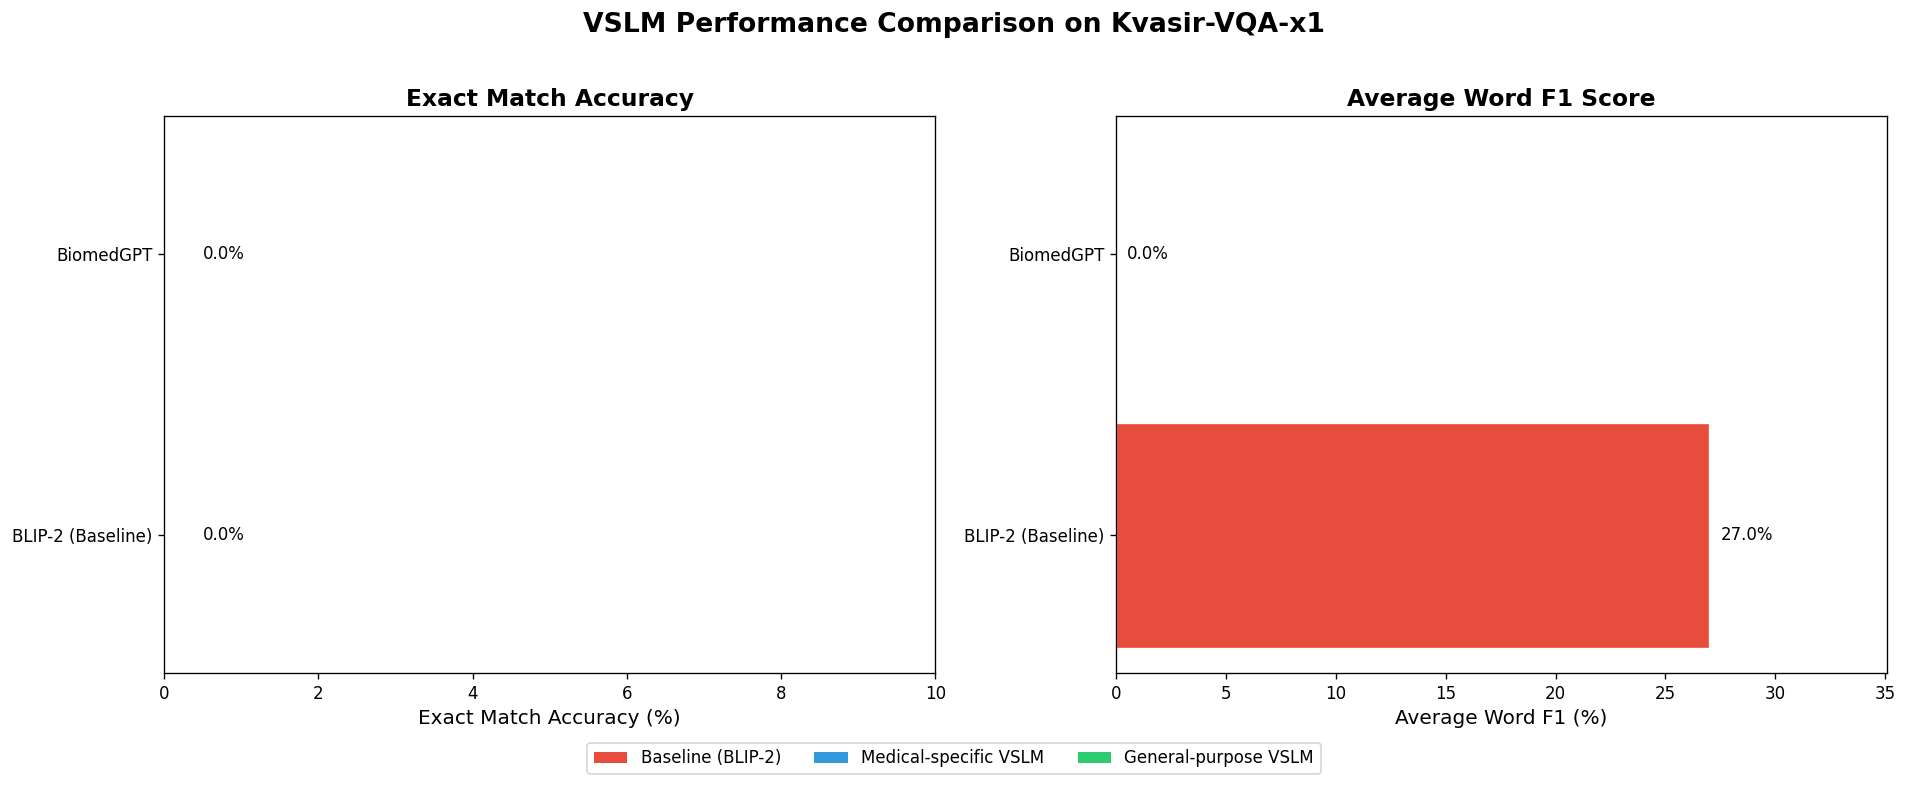

In [19]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ─── Bar Chart: Exact Match & Word F1 ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = comparison_df["Model"].tolist()
exact_match = comparison_df["Exact Match (%)"].tolist()
word_f1 = comparison_df["Avg Word F1 (%)"].tolist()

colors = ['#e74c3c' if 'Baseline' in m else '#3498db' if 'Med' in m or 'Biomed' in m
          else '#2ecc71' for m in models]

# Exact Match
bars1 = axes[0].barh(models, exact_match, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Exact Match Accuracy (%)', fontsize=12)
axes[0].set_title('Exact Match Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, max(max(exact_match) * 1.3, 10))
for bar, val in zip(bars1, exact_match):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

# Word F1
bars2 = axes[1].barh(models, word_f1, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Average Word F1 (%)', fontsize=12)
axes[1].set_title('Average Word F1 Score', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, max(max(word_f1) * 1.3, 10))
for bar, val in zip(bars2, word_f1):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

plt.suptitle('VSLM Performance Comparison on Kvasir-VQA-x1',
             fontsize=16, fontweight='bold', y=1.02)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Baseline (BLIP-2)'),
    Patch(facecolor='#3498db', label='Medical-specific VSLM'),
    Patch(facecolor='#2ecc71', label='General-purpose VSLM'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
viz_path = os.path.join(RESULTS_DIR, "vslm_comparison_chart.png")
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {viz_path}")

OSError: [Errno 28] No space left on device

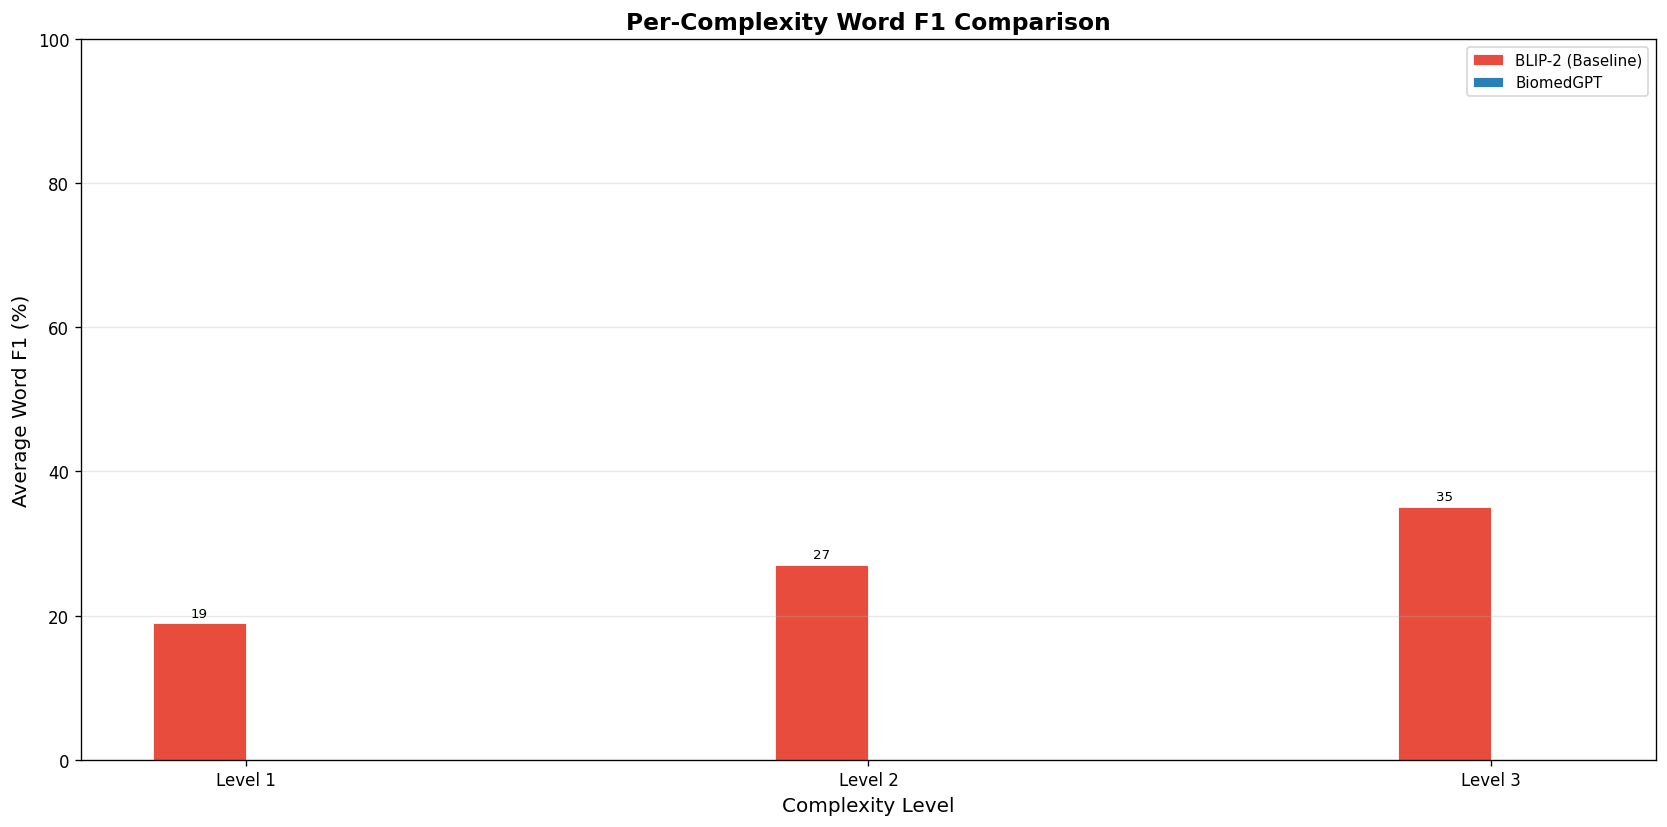

In [20]:
# ─── Per-Complexity F1 Comparison ───
fig, ax = plt.subplots(figsize=(14, 7))

# Gather per-complexity data
complexity_levels = []
for _, summary in all_summaries.items():
    for key in summary.get("per_complexity", {}).keys():
        level = key.replace("level_", "")
        if level not in complexity_levels:
            complexity_levels.append(level)
complexity_levels.sort()

x = np.arange(len(complexity_levels))
width = 0.15
n_models = len(all_summaries)

model_colors = {
    "BLIP-2 (Baseline)": "#e74c3c",
    "MoE-TinyMed": "#3498db",
    "BiomedGPT": "#2980b9",
    "TinyGPT-V": "#2ecc71",
    "MiniGPT-4": "#27ae60",
}

for i, (model_name, summary) in enumerate(all_summaries.items()):
    per_c = summary.get("per_complexity", {})
    f1_values = [per_c.get(f"level_{c}", {}).get("avg_word_f1", 0) for c in complexity_levels]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, f1_values, width,
                  label=model_name,
                  color=model_colors.get(model_name, f'C{i}'),
                  edgecolor='white', linewidth=0.5)
    # Value labels
    for bar, val in zip(bars, f1_values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Complexity Level', fontsize=12)
ax.set_ylabel('Average Word F1 (%)', fontsize=12)
ax.set_title('Per-Complexity Word F1 Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Level {c}' for c in complexity_levels])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
viz_path2 = os.path.join(RESULTS_DIR, "vslm_per_complexity_chart.png")
plt.savefig(viz_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {viz_path2}")

## 14. Conclusion & Analysis

Final answer: *Do VSLMs provide better accuracy and reliability than
the baseline model for Kvasir-VQA-x1 Visual Question Answering?*

In [21]:
print("\n" + "=" * 80)
print("  FINAL ANALYSIS: VSLMs vs BLIP-2 Baseline on Kvasir-VQA-x1")
print("=" * 80)

baseline_f1 = all_summaries.get("BLIP-2 (Baseline)", {}).get("average_word_f1", 27.0)
baseline_em = all_summaries.get("BLIP-2 (Baseline)", {}).get("exact_match_accuracy", 0.0)

print(f"\n  Baseline (BLIP-2 Zero-Shot):")
print(f"    Exact Match: {baseline_em:.1f}%  |  Avg Word F1: {baseline_f1:.1f}%")

print(f"\n  {'─' * 60}")
print(f"  VSLM Results:")

better_models = []
for model_name, summary in all_summaries.items():
    if "Baseline" in model_name:
        continue
    em = summary.get("exact_match_accuracy", 0)
    f1 = summary.get("average_word_f1", 0)
    em_diff = em - baseline_em
    f1_diff = f1 - baseline_f1

    em_arrow = "↑" if em_diff > 0 else "↓" if em_diff < 0 else "="
    f1_arrow = "↑" if f1_diff > 0 else "↓" if f1_diff < 0 else "="

    print(f"\n    {model_name}:")
    print(f"      Exact Match: {em:.1f}% ({em_arrow}{abs(em_diff):+.1f}pp vs baseline)")
    print(f"      Avg Word F1: {f1:.1f}% ({f1_arrow}{abs(f1_diff):+.1f}pp vs baseline)")

    if f1 > baseline_f1 or em > baseline_em:
        better_models.append(model_name)

print(f"\n  {'─' * 60}")
print(f"  VERDICT:")
if better_models:
    print(f"    ✓ The following VSLMs outperformed the baseline:")
    for m in better_models:
        print(f"      - {m}")
    print(f"\n    → YES, VSLMs CAN provide better performance than the")
    print(f"      generic BLIP-2 zero-shot baseline on Kvasir-VQA-x1.")
else:
    print(f"    ✗ No VSLM outperformed the baseline in this zero-shot evaluation.")
    print(f"\n    → Fine-tuning may be needed for VSLMs to outperform the baseline.")
    print(f"      This is expected, as zero-shot performance depends heavily on")
    print(f"      pre-training data overlap with the target domain.")

print(f"\n  NOTE: All models were evaluated ZERO-SHOT (no fine-tuning).")
print(f"  Fine-tuning on Kvasir-VQA-x1 training data would likely")
print(f"  improve all models significantly.")
print("=" * 80)

# Save final comparison JSON
final_path = os.path.join(RESULTS_DIR, "vslm_final_comparison.json")
with open(final_path, "w") as f:
    json.dump(all_summaries, f, indent=2)
print(f"\n[INFO] Final comparison saved to {final_path}")


  FINAL ANALYSIS: VSLMs vs BLIP-2 Baseline on Kvasir-VQA-x1

  Baseline (BLIP-2 Zero-Shot):
    Exact Match: 0.0%  |  Avg Word F1: 27.0%

  ────────────────────────────────────────────────────────────
  VSLM Results:

    BiomedGPT:
      Exact Match: 0.0% (=+0.0pp vs baseline)
      Avg Word F1: 0.0% (↓+27.0pp vs baseline)

  ────────────────────────────────────────────────────────────
  VERDICT:
    ✗ No VSLM outperformed the baseline in this zero-shot evaluation.

    → Fine-tuning may be needed for VSLMs to outperform the baseline.
      This is expected, as zero-shot performance depends heavily on
      pre-training data overlap with the target domain.

  NOTE: All models were evaluated ZERO-SHOT (no fine-tuning).
  Fine-tuning on Kvasir-VQA-x1 training data would likely
  improve all models significantly.


OSError: [Errno 28] No space left on device